In [6]:
from utils.paths import RAW_DIR,DATABASE_DIR
from preprocessing.database_manager import DatabaseManager
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import umap
import hdbscan
from hdbscan import approximate_predict

Data Correlation
1. ANN descriptors with resistivity
2. Experimental data with e2

In [4]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['r','del_r','del_EN','S','VEC','resistivity']
ann_data_corr = ann_data[cols]

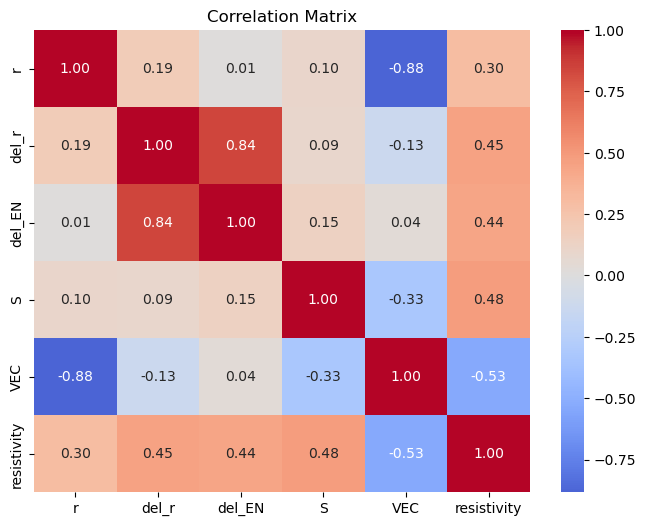

In [5]:
corr = ann_data_corr.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [9]:
#========= Experimental compositions ================
db = DatabaseManager(DATABASE_DIR/"Ternary_round1.db")

df_optical = db.table_dataframe('Optical_properties')
df_comp = db.table_dataframe('compositions')
db.close()

df_merged = df_optical.merge(df_comp, on="ID", how="inner")
tern_1550 = df_merged[np.isclose(df_merged["wavelength_nm"].astype(float), 1552.0)]

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [7]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)


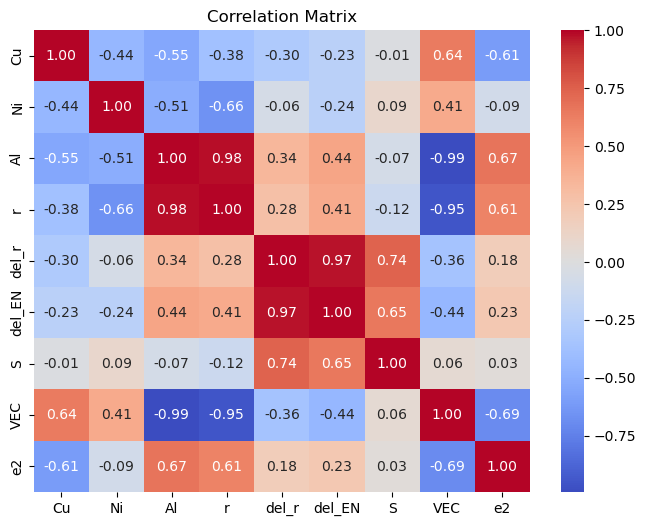

In [10]:
X = tern_1550[['Cu','Ni','Al']].copy()
y = tern_1550['e2'].copy()

df_corr = calc.transform(X)
df_corr['e2'] = y

corr = df_corr.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

ANN Data

In [2]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['r','del_r','del_EN','S','VEC']
ann_data_per = ann_data[cols]

Experimental data

In [3]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [ ]:
X_exp = comp_space[['Cu','Ni','Al']].copy()
Xexp = calc.transform(X_exp)
Xexp = Xexp[cols]

In [7]:
# Standarize
scaler = MinMaxScaler()
X_scale = scaler.fit_transform(ann_data_per)

# Apply PCA training set
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Apply PCA new points data
x_exp_scale = scaler.transform(Xexp)
x_exp_pca = pca.transform(x_exp_scale)
df_exp_pca = pd.DataFrame(x_exp_pca, columns=["PC1", "PC2"])

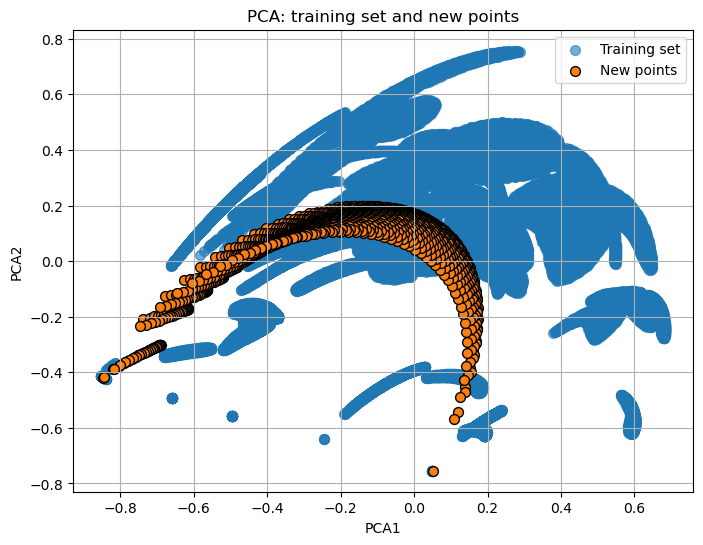

In [8]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_pca["PC1"],
    df_exp_pca["PC2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


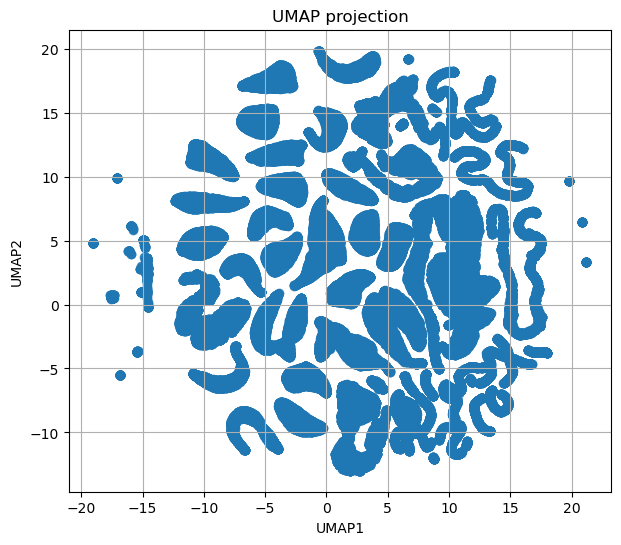

In [9]:
# UMAP model
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Fit and transform
X_umap = reducer.fit_transform(X_scale)

# Put into dataframe
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"], index=ann_data_per.index)

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(df_umap["UMAP1"], df_umap["UMAP2"], alpha=0.8)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projection")
plt.grid(True)
plt.show()

In [10]:
x_exp_scale = scaler.transform(Xexp)
x_exp_umap = reducer.transform(x_exp_scale)
df_exp_umap = pd.DataFrame(x_exp_umap, columns=["UMAP1", "UMAP2"])

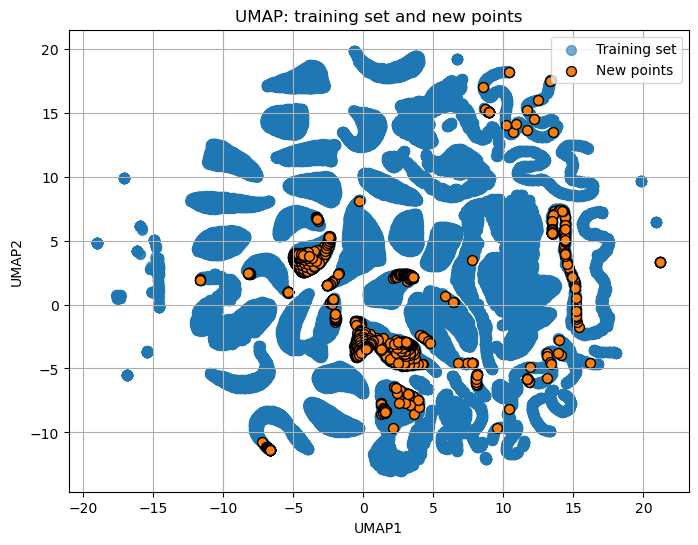

In [11]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_umap["UMAP1"],
    df_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_umap["UMAP1"],
    df_exp_umap["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

Clustering Method

In [12]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50,prediction_data=True)
labels = clusterer.fit_predict(X_umap)
df_umap["cluster"] = labels

In [13]:
# Assign clusters to experimental points
labels_exp, strengths = approximate_predict(clusterer, df_exp_umap[["UMAP1","UMAP2"]].values)
df_exp_umap["cluster"] = labels_exp
df_exp_umap["strength"] = strengths

In [14]:
#Unique clusters labels from the CuNiAl system
relevant_clusters = df_exp_umap["cluster"].unique()
relevant_clusters = relevant_clusters[relevant_clusters != -1]
print(relevant_clusters)

[32 30 29 27 22 12 21 23  6 47 64 62 53  2 41 61 39 28 26 48 20 43 51 60]


In [15]:
# Extract the data from those clusters from the dataset data
df_selected_umap = df_umap[df_umap["cluster"].isin(relevant_clusters)].copy()

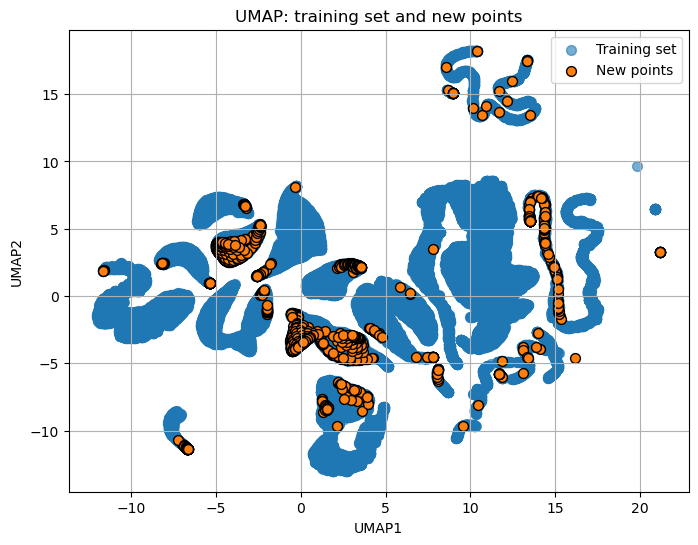

In [16]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_selected_umap["UMAP1"],
    df_selected_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

# New points
plt.scatter(
    df_exp_umap["UMAP1"],
    df_exp_umap["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="New points"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ann_data_selected = ann_data.loc[df_selected_umap.index]
ann_data_selected.to_csv("selected_data.csv",index=False)

In [24]:
ann_data_selected = ann_data_selected[cols]

selected_scale = scaler.transform(ann_data_selected)
selected_umap = reducer.transform(selected_scale)
df_sel_umap = pd.DataFrame(selected_umap, columns=["UMAP1", "UMAP2"])

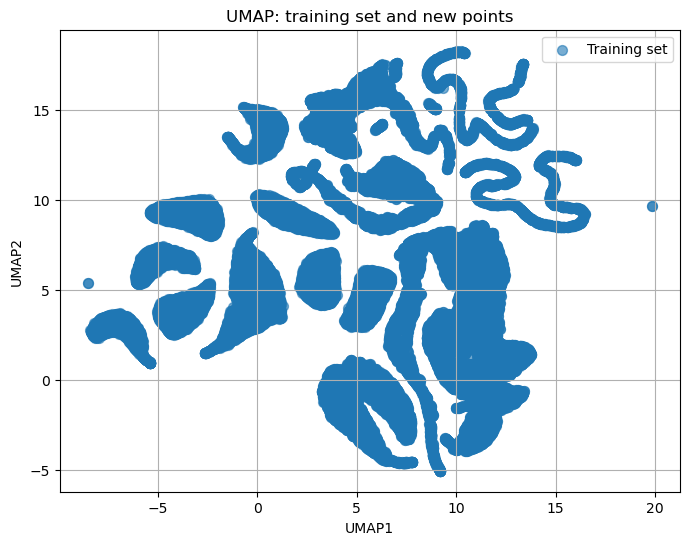

In [25]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_sel_umap["UMAP1"],
    df_sel_umap["UMAP2"],
    alpha=0.6,
    s=50,
    label="Training set"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()